PREREQUISITE

Before fitting your logistic regression model via scikit-learn, execute these crucial processing steps on the raw data:
    1.   Audit Null Values: Run [df.isnull().sum()] to identify missing entries prominently found within     the  glucose, education, and totChol features

    2. .Locally Impute: Replace numeric nulls using the column [.median()] to avoid distortions from outliers, or
       use .mode()[0] for binary markers like BPMeds.
       
    3.  Handle Multicollinearity: Calculate a correlation matrix. Ensure sysBP (systolic) and diaBP    (diastolic) blood pressures are not overly correlated, as high collinearity destabilizes logistic regression coefficients.
    
    4. Scale the Continuous Features: Apply StandardScaler to continuous fields like age, totChol, and sysBP. Logistic regression relies on gradient descent/regularization, meaning mismatched feature scales will skew model weights.

The Framingham Heart Study is a long term prospective study of the etiology of cardiovascular disease among a population of free living subjects in the community of Framingham, Massachusetts.

The enclosed dataset is a subset of the data collected as part of the Framingham study and includes laboratory, clinic, questionnaire, and adjudicated event data on 4,434 participants. Participant clinic data was collected during three examination periods, approximately 6 years apart, from roughly 1956 to 1968. Each participant was followed for a total of 24 years.

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder # for scaling and encoding
from sklearn.model_selection import train_test_split

heart_diagnostic = pd.read_csv('Framingham_heart_study.csv')
heart_diagnostic

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


Given the dataset has many columns, it is a a high-dimensional dataset hence we would need to clean it to remove irrelevant and redundant features using many methods

1. Perform exploratory data analysis
     df.info()                          # check dtypes, nulls

     df.describe()                      # spot constant/near-constant columns
     
     df.isnull().sum().sort_values(ascending=False)  # missing value audit

     Drop columns that are: 1. Constant or near-constant (no predictive value)
                            2. Mostly missing (e.g., >50% null, depending on context)

2. Check for multicollinearity
         Highly correlated features add redundancy without adding information.

3. Feature selection techniques
         process of choosing a subset of the most relevant columns (features) from your dataset, and discarding the rest, before training a model. The goal: keep only the features that actually help predict the target, and drop the ones that add noise, redundancy, or complexity without improving performance.

     a). Wrapper method -> Repeatedly trains the model, removes the weakest feature, and repeats until only  n remain.



In [3]:
heart_diagnostic.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [4]:
heart_diagnostic.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [5]:
# CHECKING THE COMPOSITION OF THE TARGET VALUE
heart_diagnostic['TenYearCHD'].unique()

array([0, 1])

In [6]:
# CHECKING IF THERE ARE ANY DUPLICATES AND REMOVING THEM

print("No. of duplicated values are: ",heart_diagnostic.duplicated().sum())

No. of duplicated values are:  0


In [7]:
# CHECKING THE NO. OF NULL VALUES IN THE FEATURES
print(heart_diagnostic.isnull().sum(),"\n")

# FILLING THE NULL VALUES WITH THE MEDIAN, MODE AND MEAN VALUES
heart_diagnostic['education'] = heart_diagnostic['education'].fillna(heart_diagnostic['education'].median())
heart_diagnostic['cigsPerDay'] = heart_diagnostic['cigsPerDay'].fillna(heart_diagnostic['cigsPerDay'].median())
heart_diagnostic['BPMeds'] = heart_diagnostic['BPMeds'].fillna(heart_diagnostic['BPMeds'].median())
heart_diagnostic['totChol'] = heart_diagnostic['totChol'].fillna(heart_diagnostic['totChol'].median())
heart_diagnostic['heartRate'] = heart_diagnostic['heartRate'].fillna(heart_diagnostic['heartRate'].median())
heart_diagnostic['BMI'] = heart_diagnostic['BMI'].fillna(heart_diagnostic['BMI'].median())
heart_diagnostic['glucose'] = heart_diagnostic['glucose'].fillna(heart_diagnostic['glucose'].median())


print(heart_diagnostic.isnull().sum())

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64 

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


In [8]:
# RENAMING FIRST COLUMN TO AVOID CONFUSION
heart_diagnostic.rename(columns={"male": "sex"}, inplace=True)

In [9]:
heart_diagnostic

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


REMOVAL OF OUTLIERS IN THE FEARTURES WITH LARGE RANGES

In [10]:
# REMOVAL OF OUTLIERS IN THE AGE FEATURE

Q1_age = heart_diagnostic['age'].quantile(0.25)
Q3_age = heart_diagnostic['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_age_bound = Q1_age - 1.5 * IQR_age
upper_age_bound = Q3_age + 1.5 * IQR_age

print(f"Outlier bounds for age: {lower_age_bound:.2f} to {upper_age_bound:.2f}")

heart_diagnostic = heart_diagnostic[(heart_diagnostic['age'] >= lower_age_bound) & (heart_diagnostic['age'] <= upper_age_bound)]

Outlier bounds for age: 21.00 to 77.00


In [11]:
# REMOVAL OF OUTLIERS IN THE TotalChol FEATURE

Q1_totChol = heart_diagnostic['totChol'].quantile(0.25)
Q3_totChol = heart_diagnostic['totChol'].quantile(0.75)
IQR_totChol = Q3_totChol - Q1_totChol
lower_totChol_bound = Q1_totChol - 1.5 * IQR_totChol
upper_totChol_bound = Q3_totChol + 1.5 * IQR_totChol

print(f"Outlier bounds for Total Cholestrol: {lower_totChol_bound:.2f} to {upper_totChol_bound:.2f}")

heart_diagnostic = heart_diagnostic[(heart_diagnostic['totChol'] >= lower_totChol_bound) & (heart_diagnostic['totChol'] <= upper_totChol_bound)]

Outlier bounds for Total Cholestrol: 122.00 to 346.00


In [12]:
# REMOVAL OF OUTLIERS IN THE sysBP FEATURE

Q1_sysBP = heart_diagnostic['sysBP'].quantile(0.25)
Q3_sysBP = heart_diagnostic['sysBP'].quantile(0.75)
IQR_sysBP = Q3_sysBP - Q1_sysBP
lower_sysBP_bound = Q1_sysBP - 1.5 * IQR_sysBP
upper_sysBP_bound = Q3_sysBP + 1.5 * IQR_sysBP

print(f"Outlier bounds for sysBP: {lower_sysBP_bound:.2f} to {upper_sysBP_bound:.2f}")

heart_diagnostic = heart_diagnostic[(heart_diagnostic['sysBP'] >= lower_sysBP_bound) & (heart_diagnostic['sysBP'] <= upper_sysBP_bound)]

Outlier bounds for sysBP: 77.25 to 183.25


In [13]:
# REMOVAL OF OUTLIERS IN THE diaBP FEATURE

Q1_diaBP = heart_diagnostic['diaBP'].quantile(0.25)
Q3_diaBP = heart_diagnostic['diaBP'].quantile(0.75)
IQR_diaBP = Q3_diaBP - Q1_diaBP
lower_diaBP_bound = Q1_diaBP - 1.5 * IQR_diaBP
upper_diaBP_bound = Q3_diaBP + 1.5 * IQR_diaBP

print(f"Outlier bounds for diaBP: {lower_diaBP_bound:.2f} to {upper_diaBP_bound:.2f}")

heart_diagnostic = heart_diagnostic[(heart_diagnostic['diaBP'] >= lower_diaBP_bound) & (heart_diagnostic['diaBP'] <= upper_diaBP_bound)]

Outlier bounds for diaBP: 52.25 to 110.25


In [14]:
# REMOVAL OF OUTLIERS IN THE BMI FEATURE

Q1_BMI = heart_diagnostic['BMI'].quantile(0.25)
Q3_BMI = heart_diagnostic['BMI'].quantile(0.75)
IQR_BMI = Q3_BMI - Q1_BMI
lower_BMI_bound = Q1_BMI - 1.5 * IQR_BMI
upper_BMI_bound = Q3_BMI + 1.5 * IQR_BMI

print(f"Outlier bounds for BMI: {lower_BMI_bound:.2f} to {upper_BMI_bound:.2f}")

heart_diagnostic = heart_diagnostic[(heart_diagnostic['BMI'] >= lower_BMI_bound) & (heart_diagnostic['BMI'] <= upper_BMI_bound)]

Outlier bounds for BMI: 15.70 to 35.26


In [17]:
heart_diagnostic.head(6)
#heart_diagnostic['education'].unique()

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0


EXPLORATORY DATA ANALYSIS

Text(0.5, 1.0, 'CORRELATION MATRIX FOR HEART DIAGNOSTIC')

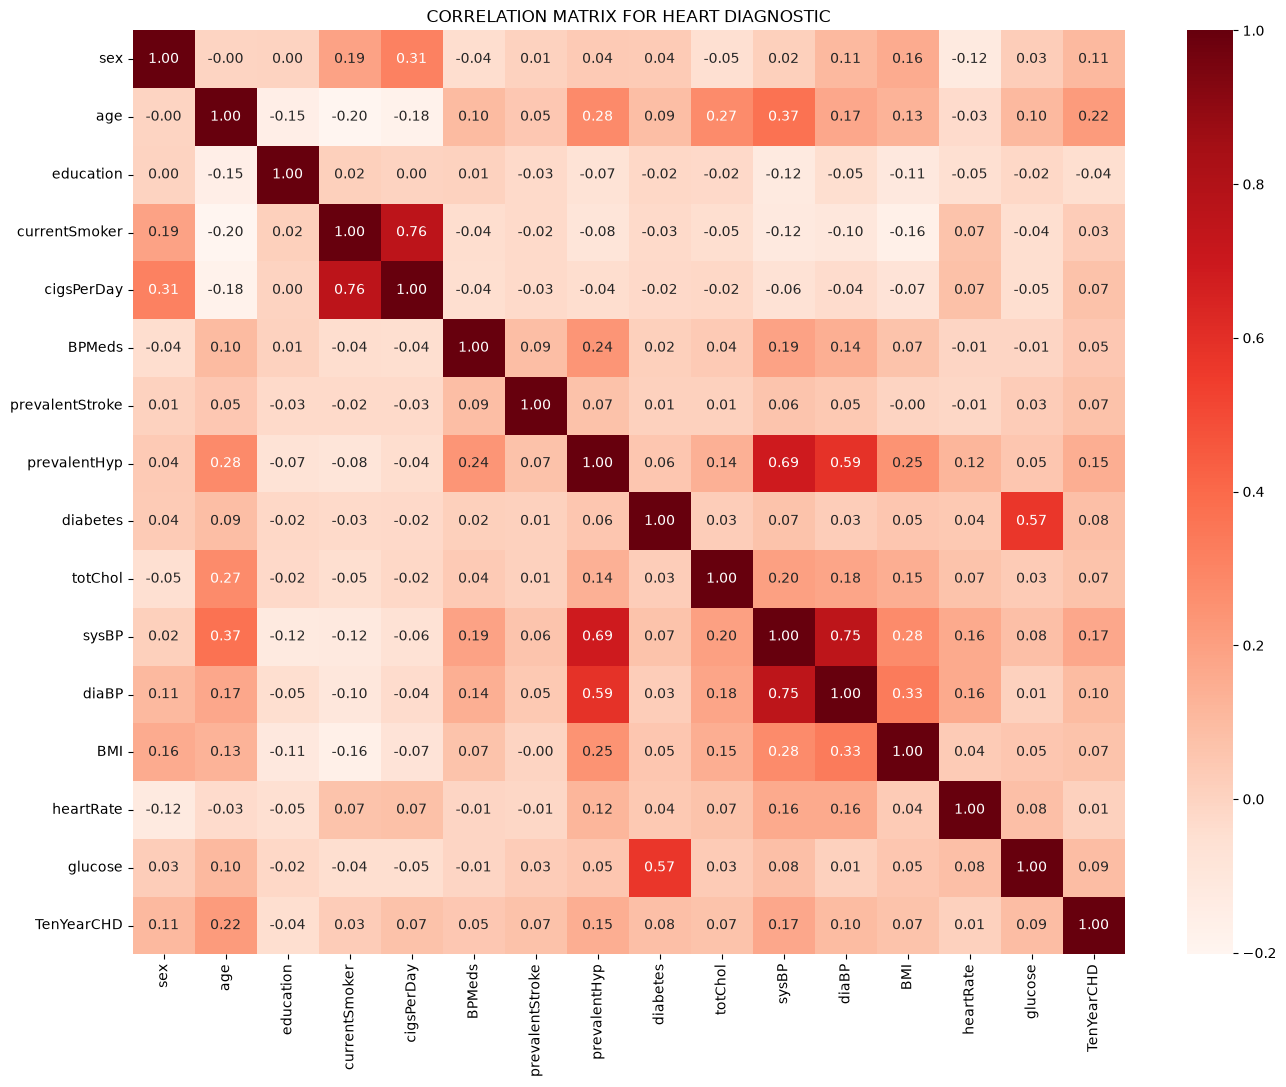

In [22]:
matrix = heart_diagnostic.corr()

plt.figure(figsize=(16, 12))  # increase width/height to fit all rows/columns
sns.heatmap(
    matrix,
    cmap='Reds',
    annot=True,
    fmt='.2f',              # rounds displayed values to 2 decimals, reduces clutter
    annot_kws={'size': 10}   # shrinks number font so it fits in each cell
    
)

plt.title("CORRELATION MATRIX FOR HEART DIAGNOSTIC")

In [28]:
#fig =px.histogram(
    #heart_diagnostic,
    #x='age',
    #y='BMI',
    #title=' GRAPH OF AGE AGAINST BMI',
    #color= 'currentSmoker'
#)

#fig.update_layout(bargap=0.1)
#fig.show()

In [27]:
heart_diagnostic.BMI.describe()

count    3936.000000
mean       25.417406
std         3.495987
min        15.960000
25%        22.930000
50%        25.230000
75%        27.760000
max        35.200000
Name: BMI, dtype: float64